In [1]:
import naima
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import ascii
from naima.models import ExponentialCutoffPowerLaw, InverseCompton

/home/vlad/Mine/miniconda3/envs/fermipy/lib/python3.9/site-packages/naima/version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [76]:
sed1 = 'SED1.dat'
sed1_data = ascii.read(sed1, format = 'ipac')

sed2 = 'SED2_HESS_100_TeV.txt'

sed2_data = ascii.read(sed2, format='ipac')
sed2_data = sed2_data[:5]

In [77]:
results_table = ascii.read("/home/vlad/Mine/NAIMA/ecpl_electrononly/SED2_100TeV/SGR_IC_results.ecsv", format='ecsv')
best_pars = results_table['median']

In [78]:
fit_amp = best_pars[0] / u.eV
fit_e0 = (10**best_pars[1]) * u.TeV
fit_alpha = best_pars[3]
fit_ecut = (10**best_pars[4]) * u.TeV

In [79]:
print(fit_amp)
print(fit_e0)
print(fit_alpha)
print(fit_ecut)

7.66518452914122e+37 1 / eV
0.06086032116614911 TeV
2.49121548105526
206.63549190546945 TeV


In [80]:
ECPL = naima.models.ExponentialCutoffPowerLaw(fit_amp, fit_e0, fit_alpha, fit_ecut)
IC = naima.models.InverseCompton(ECPL, seed_photon_fields=[["CMB", 2.7 * u.K, 0.26 * u.eV/u.cm**3],
                                                           ["FIR", 107 * u.K, 1.19 * u.eV/u.cm**3],
                                                           ["NIR", 7906 * u.K, 1.92 * u.eV/u.cm**3]])

In [81]:
SYN = naima.models.Synchrotron(ECPL, B=1*u.uG)
SYN1 = naima.models.Synchrotron(ECPL, B=5*u.uG)
spectrum_energy = np.logspace(-15,6,1000)*u.GeV
sed_SYN = SYN.sed(spectrum_energy, distance=12.5*u.kpc)
sed_IC = IC.sed(spectrum_energy, distance=12.5*u.kpc)
sed_SYN1 = SYN1.sed(spectrum_energy, distance=12.5*u.kpc)

In [82]:
E = sed2_data["energy"].to(u.GeV)
E_lo = sed2_data['energy_edge_lo'].to(u.GeV)
E_hi = sed2_data["energy_edge_hi"].to(u.GeV)
flux_2 = sed2_data["flux"].to(1/(u.cm**2*u.s*u.GeV))
flux_err_lo = sed2_data["flux_error_lo"] .to(1/(u.cm**2*u.s*u.GeV))
flux_err_hi = sed2_data["flux_error_hi"] .to(1/(u.cm**2*u.s*u.GeV))

y_errors_asymmetric = [E**2 * flux_err_lo, E**2 * flux_err_hi]

In [89]:
E = sed2_data["energy"].to(u.GeV)
E_center = (E_lo + E_hi) /2
E_bin = (E_hi-E_lo)/2

flux_1 = sed1_data["flux"].to(1/(u.cm**2*u.s*u.GeV))
flux_error_1 = sed1_data["flux_error"].to(1/(u.cm**2*u.s*u.GeV))



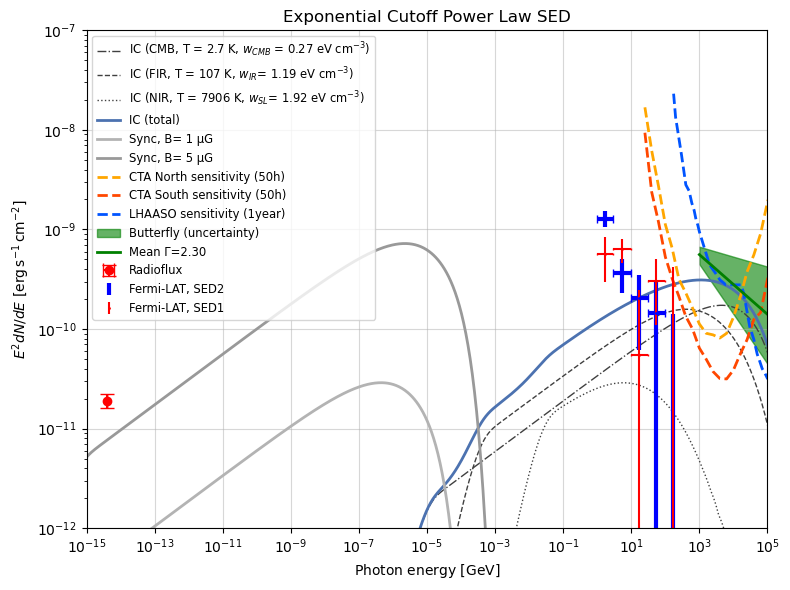

In [91]:
plt.figure(figsize=(8,6))
plt.rc('font', family='sans')
plt.rc('mathtext', fontset='custom')
for seed, deed, ls in zip(['CMB', 'FIR', 'NIR'], 
                          ['T = 2.7 K, $w_{CMB}$ = 0.27 eV $\\mathrm{cm}^{-3}$',
                           'T = 107 K, $w_{IR}$= 1.19 eV $\\mathrm{cm}^{-3}$',
                           'T = 7906 K, $w_{SL}$= 1.92 eV $\\mathrm{cm}^{-3}$'],
                          ['-.', '--', ':']):
    sed = IC.sed(spectrum_energy, distance=12.5*u.kpc, seed=seed)
    plt.loglog(spectrum_energy,624.15096*sed ,lw=1, ls=ls,label='IC ({0}, {1})'.format(seed,deed),c='0.25')
plt.loglog(spectrum_energy,624.15096*sed_IC,lw=2,label='IC (total)',c=naima.plot.color_cycle[0])
plt.loglog(spectrum_energy,sed_SYN*624.150636,lw=2, label='Sync, B= 1 µG',c=(0.7, 0.7, 0.7))
plt.loglog(spectrum_energy,sed_SYN1*624.150636,lw=2, label='Sync, B= 5 µG',c=(0.6, 0.6, 0.6))
plt.xlabel('Photon energy [{0}]'.format(
        spectrum_energy.unit.to_string('latex_inline')))
plt.ylabel('$E^2 dN/dE$ [{0}]'.format(
        sed_SYN.unit.to_string('latex_inline')))

plt.plot(x,y_n_cta,lw=2, label ='CTA North sensitivity (50h)',linestyle = 'dashed', c = (1, 0.65, 0))
plt.plot(x,y_s_cta,lw=2, label ='CTA South sensitivity (50h)',linestyle = 'dashed', c = (1, 0.28, 0))
plt.plot(x_lhaaso,y_lhaaso,lw=2, label ='LHAASO sensitivity (1year)',linestyle = 'dashed', c = (0, 0.33, 1))

plt.errorbar(x_d, y_d,label='Radioflux', xerr=x_d_error ,yerr=y_d_error ,fmt='ro', capsize=5)

plt.errorbar(E_center, flux_2 * E**2, xerr=E_bin, fmt='o', linestyle='', markersize=0, color='blue',capsize=3, lw=3)
plt.errorbar(E, flux_2 * E**2, yerr=y_errors_asymmetric, fmt='o', linestyle='', markersize=1, label='Fermi-LAT, SED2', color='blue', lw=3)

plt.errorbar(E_center, flux_1 * E**2, xerr=E_bin, fmt='o', linestyle='', markersize=0, color='red',capsize=1)
plt.errorbar(E, flux_1 * E**2, yerr=flux_error_1.T * E**2, fmt='o', linestyle='', markersize=1, label='Fermi-LAT, SED1', color='red')

butterfly_hess(E_norm_2, E_range_2, F_int, Gamma_mean, Gamma_err, F_rel_err=0.2)

plt.ylim(1e-12, 1e-7)
plt.xlim(1e-15, 10**5)
plt.xticks(ticks=[1e-15, 1e-13, 1e-11, 1e-9, 1e-7, 1e-5, 1e-3, 1e-1, 1e1, 1e3, 1e5])
plt.grid(alpha=0.5)
plt.title('Exponential Cutoff Power Law SED', loc='center')
plt.tight_layout()
plt.legend(loc='upper left', fontsize='small')
#plt.savefig('PWN-ECPL_plot_for100TeV.png')

In [85]:
x = [ 25.11886, 39.81072, 63.09573, 100, 158.48932, 251.18864, 398.10717, 630.95734, 1000,	1584.89319,	2511.88643,	3981.07171,	6309.57344,	10000, 15848.93192,	25118.86432, 39810.71706, 63095.73445, 100000, 158489.31925]
y_n_cta = [ 0.0000000168521,	0.00000000617909,	0.00000000271506,	0.00000000112347,	0.000000000649117,	0.000000000315196,	0.000000000230936,	0.000000000162279,	0.000000000112347,	0.0000000000905018,	0.0000000000873811,	0.0000000000811396,	0.0000000000905018,	0.000000000131072,	0.00000000020909,	0.00000000037449,	0.000000000555494,	0.00000000091126,	0.00000000188493,	0.00000000312075]
y_s_cta = [	0.00000000936226,	0.00000000237177,	0.00000000118589,	0.000000000530528,	0.000000000321438,	0.000000000212211,	0.000000000134192,	0.0000000000998641,	0.0000000000642875,	0.0000000000497448,	0.000000000037449,	0.0000000000318317,	0.0000000000315196,	0.0000000000386973,	0.0000000000558615,	0.0000000000780188,	0.00000000012483,	0.000000000146675,	0.000000000315196,	0.000000000508683]

x_lhaaso = [175, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 16500, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000]
y_lhaaso = [0.0000000230936, 0.0000000134192, 0.00000000555494, 0.00000000280868, 0.00000000243419, 0.00000000184124, 0.00000000156038, 0.0000000012483, 0.00000000110475, 0.000000000948709, 0.000000000440026, 0.000000000362007, 0.000000000312075, 0.000000000293351, 0.000000000277747, 0.000000000277747, 0.000000000277747, 0.000000000277747, 0.000000000277747, 0.000000000277747, 0.000000000230936, 0.000000000106106, 0.0000000000780188, 0.0000000000558615, 0.0000000000468113, 0.0000000000399456, 0.000000000037137, 0.0000000000343283, 0.0000000000318317, 0.0000000000318317, 0.0000000000362007, 0.0000000000355766, 0.0000000000511804, 0.0000000000624151, 0.0000000000905018, 0.000000000106106, 0.0000000001473, 0.000000000188493]


x_d= 4*10**(-15)
y_d= 1.9*10**(-11)
x_d_error=0
y_d_error=0.3*10**(-11)


In [86]:
def butterfly_hess(E_norm_2, E_range_2, F_int, Gamma_mean, Gamma_err, F_rel_err=0.2):
    """
    Побудова 'butterfly' для степеневого закону з невизначеністю у нормі та індексі.
    F_int — інтегральний потік вище E_norm (у cm^-2 s^-1)
    """
    
    # Обчислення N0 для середнього індексу
    N0_mean = F_int * (Gamma_mean - 1) / E_norm_2

    # Межі невизначеностей
    norm_range = (N0_mean * (1 - F_rel_err), N0_mean * (1 + F_rel_err))
    index_range = (Gamma_mean - Gamma_err, Gamma_mean + Gamma_err)

    # Масив енергій
    E = np.logspace(np.log10(E_range_2[0]), np.log10(E_range_2[1]), 200)

    # Створення сітки параметрів
    norms = np.linspace(norm_range[0], norm_range[1], 100)
    indices = np.linspace(index_range[0], index_range[1], 100)
    norm_grid, index_grid = np.meshgrid(norms, indices, indexing='ij')

    # Обчислення E^2 dN/dE для всіх комбінацій
    y_grid = norm_grid[np.newaxis, :, :] * (E[:, np.newaxis, np.newaxis] / E_norm_2) ** (-index_grid[np.newaxis, :, :])
    E2dNdE_grid = (E[:, np.newaxis, np.newaxis] ** 2) * y_grid

    # Межі по y
    y_min = np.min(E2dNdE_grid, axis=(1, 2))
    y_max = np.max(E2dNdE_grid, axis=(1, 2))
    y_mean = (E ** 2) * N0_mean * (E / E_norm_2) ** (-Gamma_mean)

    # Графік
    plt.fill_between(E, y_min, y_max, color='green', alpha=0.6, label='Butterfly (uncertainty)')
    plt.plot(E, y_mean, color='green', lw=2, label=f'Mean Γ={Gamma_mean:.2f}')

    plt.xscale('log')
    plt.yscale('log')
    plt.legend()



# === Приклад використання ===
E_norm_2 = 1000  # TeV
E_range_2 = (1000.0, 100000.0)  # TeV
F_int = 4.3e-13  # cm^-2 s^-1
Gamma_mean = 2.3
Gamma_err = 0.2